In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [65]:
df = pd.read_csv("professional_sales_dataset.csv")
df.head()

,Date,Region,Product,Customer_Segment,Sales_Units,Unit_Price,Discount,Shipping_Cost,Profit_Margin,Returns,Revenue
0,2023-04-13,East,Desktop,Consumer,8.0,NaN,0.10,7.34,0.11,0,4705.63
1,2023-12-15,East,Monitor,Home Office,11.0,934.22,0.05,5.58,0.12,0,9762.60
2,2023-09-28,North,Desktop,Consumer,8.0,965.85,NaN,40.80,0.19,0,6567.78
3,2023-04-17,South,Smartphone,Consumer,9.0,NaN,0.05,26.47,0.15,0,4771.41
4,2023-03-13,South,Laptop,Corporate,8.0,507.54,0.15,10.89,0.20,0,3451.27


In [66]:
print("\nData info:\n",df.info)
print("\nN.o of missing values in each column:\n",df.isnull().sum())
print("\nSummary Statistics for both Numeric and category columns:\n",df.describe(include='all'))



Data info:
 <bound method DataFrame.info of            Date Region     Product Customer_Segment  Sales_Units  Unit_Price  \
0    2023-04-13   East     Desktop         Consumer          8.0         NaN   
1    2023-12-15   East     Monitor      Home Office         11.0      934.22   
2    2023-09-28  North     Desktop         Consumer          8.0      965.85   
3    2023-04-17  South  Smartphone         Consumer          9.0         NaN   
4    2023-03-13  South      Laptop        Corporate          8.0      507.54   
..          ...    ...         ...              ...          ...         ...   
995  2023-02-07   West     Monitor         Consumer         11.0      438.57   
996  2023-10-20   West      Laptop         Consumer         15.0      430.61   
997  2023-05-19   East     Monitor      Home Office         10.0      573.35   
998  2023-12-22   East     Monitor         Consumer          9.0      827.92   
999  2023-11-29   West     Monitor         Consumer         15.0      425.5

In [67]:
df["Sales_Units"].fillna(df["Sales_Units"].median(), inplace=True)

/tmp/ipython-input-1665812672.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sales_Units"].fillna(df["Sales_Units"].median(), inplace=True)


In [68]:
df["Date"]=pd.to_datetime(df["Date"])
df["Month"]=df["Date"].dt.to_period('M').astype(str)

/tmp/ipython-input-1917309174.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["Revenue"].head(10), y=df["Sales_Units"].head(10), ax=ax, palette="viridis")


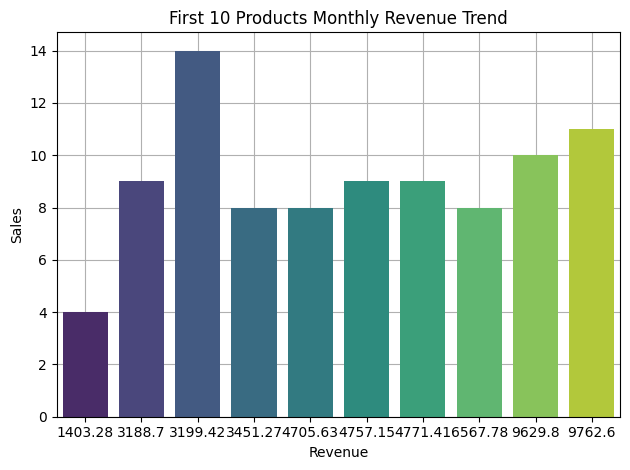

<Figure size 640x480 with 0 Axes>

In [69]:
fig,ax = plt.subplots()
sns.barplot(x=df["Revenue"].head(10), y=df["Sales_Units"].head(10), ax=ax, palette="viridis")
ax.set_xlabel("Revenue")
ax.set_ylabel("Sales")
ax.set_title("First 10 Products Monthly Revenue Trend")
plt.grid()
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()

/tmp/ipython-input-2640608903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Revenue'].head(10), y=df['Region'].head(10), ax=ax, palette="bright")


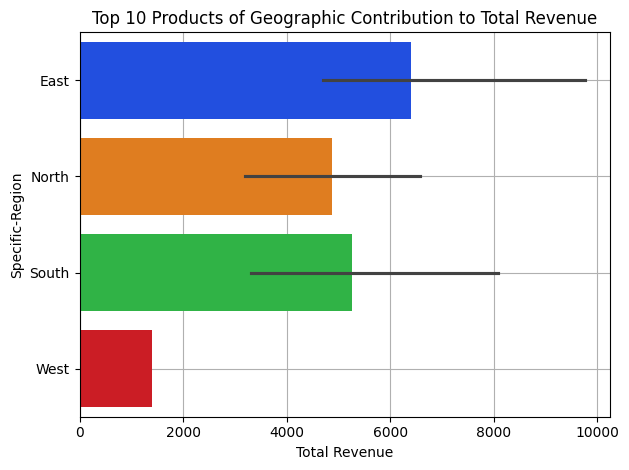

<Figure size 640x480 with 0 Axes>

In [70]:
fig,ax = plt.subplots()
sns.barplot(x=df['Revenue'].head(10), y=df['Region'].head(10), ax=ax, palette="bright")
ax.set_xlabel('Total Revenue')
ax.set_ylabel('Specific-Region')
ax.set_title('Top 10 Products of Geographic Contribution to Total Revenue')
plt.grid()
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()

/tmp/ipython-input-3236125047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product', y='Sales_Units', data=df, ax=ax, palette="dark")


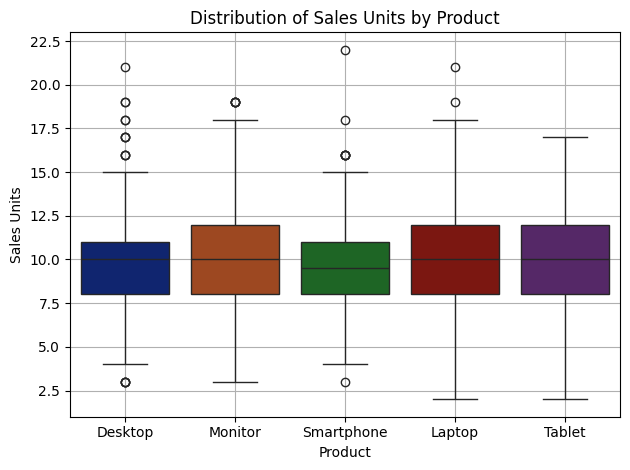

<Figure size 640x480 with 0 Axes>

In [71]:
fig,ax = plt.subplots()
sns.boxplot(x='Product', y='Sales_Units', data=df, ax=ax, palette="dark")
ax.set_xlabel('Product')
ax.set_ylabel('Sales Units')
ax.set_title('Distribution of Sales Units by Product')
plt.grid()
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()

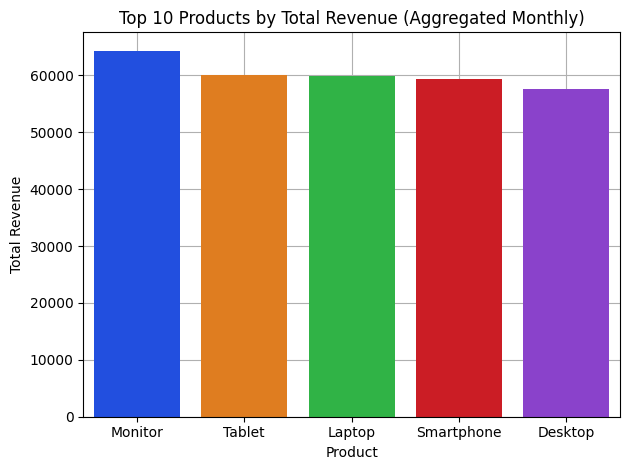

<Figure size 640x480 with 0 Axes>

In [72]:
fig,ax = plt.subplots()
axs = df.pivot_table(index="Month", columns="Product", values="Revenue")

# Calculate total revenue per product from the 'axs' pivot table
total_revenue_by_product = axs.sum().sort_values(ascending=False).reset_index()
total_revenue_by_product.columns = ['Product', 'Total Revenue']

# Plot the top 10 products by total revenue
sns.barplot(x='Product', y='Total Revenue', hue='Product', data=total_revenue_by_product.head(10), ax=ax, palette="bright", legend=False)
ax.set_xlabel('Product')
ax.set_ylabel('Total Revenue')
ax.set_title('Top 10 Products by Total Revenue (Aggregated Monthly)')
plt.grid()
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()

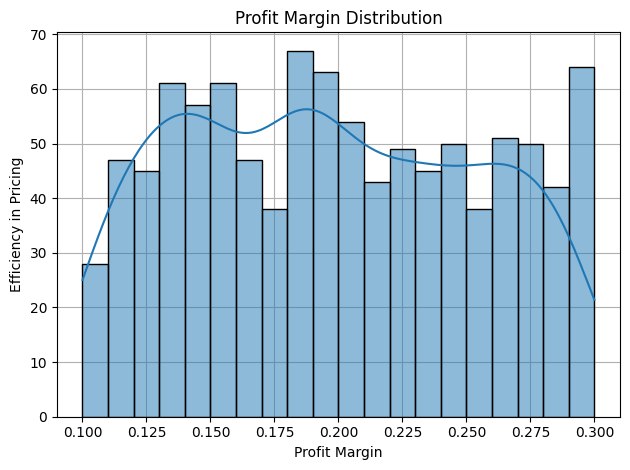

<Figure size 640x480 with 0 Axes>

In [73]:
fig,ax = plt.subplots()
sns.histplot(df["Profit_Margin"], kde=True, bins=20)
plt.xlabel("Profit Margin")
plt.ylabel("Efficiency in Pricing")
plt.title("Profit Margin Distribution")
plt.grid()
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()



/tmp/ipython-input-2491896883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Returns'], y=df['Product'], ax=ax, palette="bright")


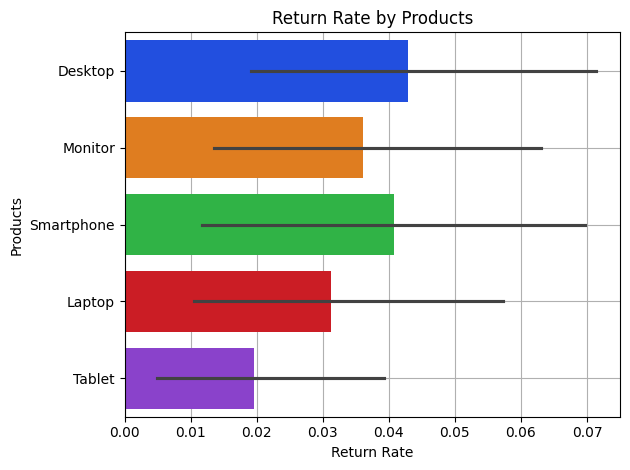

<Figure size 640x480 with 0 Axes>

In [74]:
fig,ax = plt.subplots()
sns.barplot(x=df['Returns'], y=df['Product'], ax=ax, palette="bright")
ax.set_xlabel('Return Rate')
ax.set_ylabel('Products')
ax.set_title('Return Rate by Products')
plt.grid()
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()

/tmp/ipython-input-16892125.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=df['Revenue'].head(10), y=df['Discount'].head(10), ax=ax, palette="bright")


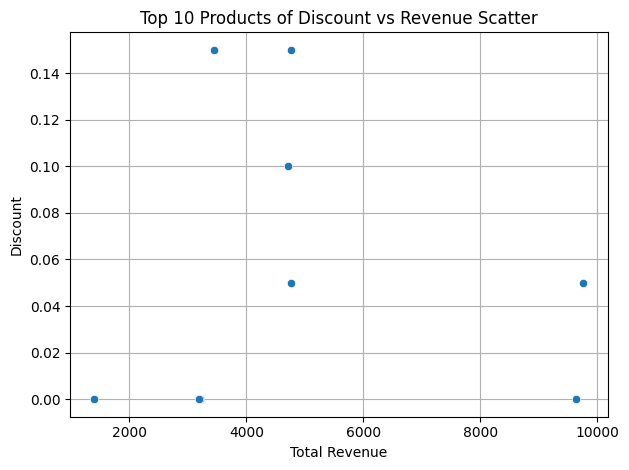

<Figure size 640x480 with 0 Axes>

In [75]:
fig,ax = plt.subplots()
sns.scatterplot(x=df['Revenue'].head(10), y=df['Discount'].head(10), ax=ax, palette="bright")
ax.set_xlabel('Total Revenue')
ax.set_ylabel('Discount')
ax.set_title('Top 10 Products of Discount vs Revenue Scatter')
plt.grid()
ax.set_axisbelow(True)
plt.tight_layout()
plt.figure()
plt.show()

In [76]:
top_dates=df.groupby("Date")["Revenue"].sum().sort_values(ascending=False).head(5)

In [77]:
df.to_csv("Cleaned_sales_dataset.csv",index=False)

In [79]:
print("\n Name: SanjayKumaran.D\n College: Vel Tech Multi tech Dr.Rangarajan Dr.Sakunthala Engineering College\n Email: sanjaykumaran6907@gmail.com")


 Name: SanjayKumaran.D
 College: Vel Tech Multi tech Dr.Rangarajan Dr.Sakunthala Engineering College
 Email: sanjaykumaran6907@gmail.com
